  # 02 — Initial Distance-Based Testing on FPCA Scores



  This notebook evaluates initial distance-based classifiers on sampled

  Gaia XP spectra after FPCA projection.



  Input:

  - `xp_sampled_spectra.csv`



  Main pipeline:

  1. load sampled spectra

  2. align labels

  3. apply row-wise L2 normalization

  4. split data into train and test sets

  5. perform FPCA using SVD

  6. classify FPCA scores with distance-based models



  Models:

  - Centroid

  - Medoid

  - kNN

  - Weighted kNN



  Distances:

  - Euclidean

  - Manhattan

  - Cosine

  - Correlation

  - Standardized Euclidean

  - Mahalanobis



  Evaluation:

  - Accuracy

  - Precision

  - Recall (Sensitivity)

  - Specificity

  - F1-score



  Main exported outputs:

  - fpca_distance_results.csv

  - fpca_distance_best_by_j.csv

  - fpca_explained_variance.csv

  - fig_fpca_cumulative_variance.svg

  - fig_top_fpca_models.svg

  - fig_fpca_eigenspectra.svg

  - fig_class_mean_spectra_fpca_input.svg

  - fig_class_mean_difference_fpca_input.svg

In [1]:
from __future__ import annotations

import warnings
from IPython.display import display
from pathlib import Path
from typing import Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.metrics import pairwise_distances
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


  ## 1. Configuration

In [2]:
DATA_DIR = Path.cwd() / "og_data"
OUT_DIR = Path.cwd() / "results" / "02_initial_model_testing"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLED_CANDIDATES = [
    DATA_DIR / "xp_sampled_spectra.csv",
]

TEST_SIZE = 0.20
K_DEFAULT = 5

J_VALUES = [5, 10, 20, 30]

DISTANCES = [
    "euclidean",
    "manhattan",
    "cosine",
    "correlation",
    "seuclidean",
    "mahalanobis",
]

TOP_N_PLOT = 12


  ## 2. Plot style

In [3]:
COLOR_PRIMARY = "#6193CD"
COLOR_SECONDARY = "#8C8C8C"
COLOR_DARK = "#4A4A4A"
COLOR_LIGHT = "#D9D9D9"
COLOR_TEXT = "#222222"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
    "axes.labelcolor": COLOR_TEXT,
    "xtick.color": COLOR_TEXT,
    "ytick.color": COLOR_TEXT,
    "text.color": COLOR_TEXT,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})


def apply_clean_axes(ax, add_grid: bool = False) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if add_grid:
        ax.grid(True, axis="x", linestyle="--", linewidth=0.6, alpha=0.5, color=COLOR_LIGHT)
    else:
        ax.grid(False)


def save_fig(path: Path) -> None:
    plt.tight_layout()
    plt.savefig(path, format="svg", bbox_inches="tight", facecolor="white")
    plt.close()


  ## 3. Helper functions

In [4]:
def find_first_existing(paths: Sequence[Path]) -> Optional[Path]:
    for path in paths:
        if path.exists():
            return path
    return None


def l2_normalize_rows(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms = np.maximum(norms, eps)
    return X / norms


def evaluate_binary(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def fit_mahalanobis_matrix(X_tr: np.ndarray, y_tr: np.ndarray, eps: float = 1e-4) -> np.ndarray:
    n_features = X_tr.shape[1]
    S = np.zeros((n_features, n_features))

    classes = np.unique(y_tr)
    for cls in classes:
        X_cls = X_tr[y_tr == cls]
        diff = X_cls - X_cls.mean(axis=0)
        S += diff.T @ diff

    denom = max(len(X_tr) - len(classes), 1)
    S /= denom
    S += eps * np.eye(n_features)

    return np.linalg.pinv(S)


def pairwise_distance_train_test(
    X_te: np.ndarray,
    X_tr: np.ndarray,
    metric_name: str,
    y_tr: Optional[np.ndarray] = None,
) -> np.ndarray:
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_tr, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_tr, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_tr, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_tr, metric="correlation")

    if metric_name == "seuclidean":
        V = np.var(X_tr, axis=0, ddof=1)
        V = np.where(V <= 1e-12, 1e-12, V)
        return pairwise_distances(X_te, X_tr, metric="seuclidean", V=V)

    if metric_name == "mahalanobis":
        VI = fit_mahalanobis_matrix(X_tr, y_tr)
        return pairwise_distances(X_te, X_tr, metric="mahalanobis", VI=VI)

    raise ValueError(f"Unknown metric: {metric_name}")


def pairwise_distance_to_reference(
    X_te: np.ndarray,
    X_ref: np.ndarray,
    X_tr_ref: np.ndarray,
    metric_name: str,
    y_tr: Optional[np.ndarray] = None,
) -> np.ndarray:
    if metric_name == "euclidean":
        return pairwise_distances(X_te, X_ref, metric="euclidean")

    if metric_name == "manhattan":
        return pairwise_distances(X_te, X_ref, metric="manhattan")

    if metric_name == "cosine":
        return pairwise_distances(X_te, X_ref, metric="cosine")

    if metric_name == "correlation":
        return pairwise_distances(X_te, X_ref, metric="correlation")

    if metric_name == "seuclidean":
        V = np.var(X_tr_ref, axis=0, ddof=1)
        V = np.where(V <= 1e-12, 1e-12, V)
        return pairwise_distances(X_te, X_ref, metric="seuclidean", V=V)

    if metric_name == "mahalanobis":
        VI = fit_mahalanobis_matrix(X_tr_ref, y_tr)
        return pairwise_distances(X_te, X_ref, metric="mahalanobis", VI=VI)

    raise ValueError(f"Unknown metric: {metric_name}")


def centroid_predict(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, metric_name: str) -> np.ndarray:
    c0 = X_tr[y_tr == 0].mean(axis=0, keepdims=True)
    c1 = X_tr[y_tr == 1].mean(axis=0, keepdims=True)
    refs = np.vstack([c0, c1])

    D = pairwise_distance_to_reference(X_te, refs, X_tr, metric_name, y_tr)
    return np.argmin(D, axis=1)


def get_class_medoid(X_cls: np.ndarray, X_tr_ref: np.ndarray, y_tr: np.ndarray, metric_name: str) -> np.ndarray:
    if len(X_cls) == 1:
        return X_cls[0:1]

    D = pairwise_distance_to_reference(X_cls, X_cls, X_tr_ref, metric_name, y_tr)
    medoid_idx = np.argmin(D.sum(axis=1))
    return X_cls[medoid_idx:medoid_idx + 1]


def medoid_predict(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, metric_name: str) -> np.ndarray:
    m0 = get_class_medoid(X_tr[y_tr == 0], X_tr, y_tr, metric_name)
    m1 = get_class_medoid(X_tr[y_tr == 1], X_tr, y_tr, metric_name)
    refs = np.vstack([m0, m1])

    D = pairwise_distance_to_reference(X_te, refs, X_tr, metric_name, y_tr)
    return np.argmin(D, axis=1)


def knn_predict(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, metric_name: str, k: int) -> np.ndarray:
    D = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    idx = np.argsort(D, axis=1)[:, :k]
    return (y_tr[idx].mean(axis=1) > 0.5).astype(int)


def weighted_knn_predict(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    metric_name: str,
    k: int,
    eps: float = 1e-8,
) -> np.ndarray:
    D = pairwise_distance_train_test(X_te, X_tr, metric_name, y_tr)
    idx = np.argsort(D, axis=1)[:, :k]

    d_k = np.take_along_axis(D, idx, axis=1)
    y_k = y_tr[idx]

    weights = 1.0 / (d_k + eps)
    weighted_prob = (weights * y_k).sum(axis=1) / weights.sum(axis=1)

    return (weighted_prob > 0.5).astype(int)


def fpca_fit_transform(
    X_tr: np.ndarray,
    X_te: np.ndarray,
    J: int,
):
    mu = X_tr.mean(axis=0)
    X_tr_c = X_tr - mu
    X_te_c = X_te - mu

    _, S, Vt = np.linalg.svd(X_tr_c, full_matrices=False)

    variances = (S ** 2) / max(len(X_tr) - 1, 1)
    explained_ratio = variances / variances.sum()

    J_eff = min(J, Vt.shape[0])
    Vj = Vt[:J_eff].T

    xi_tr = X_tr_c @ Vj
    xi_te = X_te_c @ Vj

    return xi_tr, xi_te, explained_ratio, variances[:J_eff], mu, Vt


def run_distance_models(
    X_tr: np.ndarray,
    X_te: np.ndarray,
    y_tr: np.ndarray,
    y_te: np.ndarray,
    feature_space: str,
    distances: list[str],
    k: int,
) -> list[dict]:
    rows = []

    for dist_name in distances:
        y_pred_cent = centroid_predict(X_tr, y_tr, X_te, dist_name)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": "Centroid",
            **evaluate_binary(y_te, y_pred_cent),
        })

        y_pred_med = medoid_predict(X_tr, y_tr, X_te, dist_name)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": "Medoid",
            **evaluate_binary(y_te, y_pred_med),
        })

        y_pred_knn = knn_predict(X_tr, y_tr, X_te, dist_name, k)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": f"kNN (k={k})",
            **evaluate_binary(y_te, y_pred_knn),
        })

        y_pred_wknn = weighted_knn_predict(X_tr, y_tr, X_te, dist_name, k)
        rows.append({
            "representation": "Sampled spectra",
            "feature_space": feature_space,
            "distance": dist_name,
            "model": f"Weighted kNN (k={k})",
            **evaluate_binary(y_te, y_pred_wknn),
        })

    return rows


  ## 4. Load sampled spectra

In [5]:
sampled_path = find_first_existing(SAMPLED_CANDIDATES)

if sampled_path is None:
    raise FileNotFoundError(
        "No sampled spectra dataset found. Expected one of: "
        f"{[path.name for path in SAMPLED_CANDIDATES]}"
    )

df = pd.read_csv(sampled_path)
df["source_id"] = df["source_id"].astype(str)

wl_cols = sorted(
    [col for col in df.columns if col.startswith("wl_")],
    key=lambda col: int(col.split("_")[1]),
)

if not wl_cols:
    raise ValueError(
        "Sampled spectra file must contain wide wavelength columns "
        "(for example: wl_336, wl_338, ...)."
    )

if "y" not in df.columns:
    raise ValueError(
        "Sampled spectra file must contain a 'y' column. "
        "Use the aligned file from the previous notebook if needed."
    )

wavelengths = np.array([int(col.split("_")[1]) for col in wl_cols], dtype=float)

X_raw = df[wl_cols].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=int)

print("Using file:", sampled_path.name)
print("Dataset shape:", df.shape)
print("Sampled matrix shape:", X_raw.shape)
print("Wavelength range:", f"{wavelengths[0]:.0f}–{wavelengths[-1]:.0f} nm")
print("\nClass balance:")
print(pd.Series(y).map({0: "nedvinarė", 1: "dvinarė"}).value_counts())


Using file: xp_sampled_spectra.csv
Dataset shape: (2815, 345)
Sampled matrix shape: (2815, 343)
Wavelength range: 336–1020 nm

Class balance:
nedvinarė    2257
dvinarė       558
Name: count, dtype: int64


  ## 5. Normalize sampled spectra



  Unlike the coefficient representation, sampled spectra are normalized here

  to emphasize spectral shape rather than overall scale.

In [6]:
X = l2_normalize_rows(X_raw)

raw_norms = np.linalg.norm(X_raw, axis=1)
normed_norms = np.linalg.norm(X, axis=1)

print("Any missing values:", np.isnan(X).any())

print("\nRaw sampled row-norm summary:")
display(pd.Series(raw_norms).describe())

print("\nNormalized sampled row-norm summary:")
display(pd.Series(normed_norms).describe().round(6))


Any missing values: False

Raw sampled row-norm summary:


count    2.815000e+03
mean     2.475185e-15
std      1.351281e-14
min      6.110590e-17
25%      3.396496e-16
50%      7.016139e-16
75%      1.614415e-15
max      5.323431e-13
dtype: float64


Normalized sampled row-norm summary:


count    2815.000000
mean        0.002475
std         0.013513
min         0.000061
25%         0.000340
50%         0.000702
75%         0.001614
max         0.532343
dtype: float64

  ## 6. Train/test split

In [7]:
idx_all = np.arange(len(y))

idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx_all,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_tr = X[idx_tr]
X_te = X[idx_te]

print("Train size:", len(idx_tr))
print("Test size:", len(idx_te))


Train size: 2252
Test size: 563


  ## 7. FPCA across several dimensions

In [8]:
results = []
fpca_info_rows = []

for J in J_VALUES:
    xi_tr, xi_te, explained_ratio, variances, mu_train, Vt = fpca_fit_transform(X_tr, X_te, J)

    fpca_info_rows.append({
        "J": len(variances),
        "cum_explained_variance": explained_ratio[:len(variances)].sum(),
    })

    results.extend(
        run_distance_models(
            X_tr=xi_tr,
            X_te=xi_te,
            y_tr=y_tr,
            y_te=y_te,
            feature_space=f"FPCA (J={len(variances)})",
            distances=DISTANCES,
            k=K_DEFAULT,
        )
    )

results_df = pd.DataFrame(results)

metric_cols = ["accuracy", "precision", "recall", "sensitivity", "specificity", "f1"]
results_df[metric_cols] = results_df[metric_cols].round(3)

print("\n=== RESULTS ===")
display(results_df)



=== RESULTS ===


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1
0,Sampled spectra,FPCA (J=5),euclidean,Centroid,0.334,0.203,0.804,0.804,0.217,0.324
1,Sampled spectra,FPCA (J=5),euclidean,Medoid,0.554,0.225,0.509,0.509,0.565,0.312
2,Sampled spectra,FPCA (J=5),euclidean,kNN (k=5),0.817,0.576,0.304,0.304,0.945,0.398
3,Sampled spectra,FPCA (J=5),euclidean,Weighted kNN (k=5),0.813,0.554,0.321,0.321,0.936,0.407
4,Sampled spectra,FPCA (J=5),manhattan,Centroid,0.336,0.204,0.804,0.804,0.220,0.325
...,...,...,...,...,...,...,...,...,...,...
91,Sampled spectra,FPCA (J=30),seuclidean,Weighted kNN (k=5),0.865,0.743,0.491,0.491,0.958,0.591
92,Sampled spectra,FPCA (J=30),mahalanobis,Centroid,0.334,0.203,0.804,0.804,0.217,0.324
93,Sampled spectra,FPCA (J=30),mahalanobis,Medoid,0.561,0.229,0.509,0.509,0.574,0.316
94,Sampled spectra,FPCA (J=30),mahalanobis,kNN (k=5),0.815,0.559,0.339,0.339,0.933,0.422


  ## 8. Best models by F1

In [9]:
best_df = results_df.sort_values("f1", ascending=False).reset_index(drop=True)

print("\n=== TOP MODELS BY F1 ===")
display(best_df.head(20))



=== TOP MODELS BY F1 ===


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1
0,Sampled spectra,FPCA (J=30),seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660
1,Sampled spectra,FPCA (J=20),seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626
2,Sampled spectra,FPCA (J=20),seuclidean,Weighted kNN (k=5),0.877,0.803,0.509,0.509,0.969,0.623
3,Sampled spectra,FPCA (J=20),seuclidean,kNN (k=5),0.877,0.803,0.509,0.509,0.969,0.623
4,Sampled spectra,FPCA (J=20),correlation,Weighted kNN (k=5),0.858,0.678,0.545,0.545,0.936,0.604
5,Sampled spectra,FPCA (J=20),correlation,kNN (k=5),0.856,0.674,0.536,0.536,0.936,0.597
6,Sampled spectra,FPCA (J=10),seuclidean,kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596
7,Sampled spectra,FPCA (J=10),seuclidean,Weighted kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596
8,Sampled spectra,FPCA (J=30),seuclidean,Weighted kNN (k=5),0.865,0.743,0.491,0.491,0.958,0.591
9,Sampled spectra,FPCA (J=30),seuclidean,kNN (k=5),0.865,0.743,0.491,0.491,0.958,0.591


  ## 9. Best model within each FPCA dimension

In [10]:
best_by_j_df = (
    results_df
    .sort_values(["feature_space", "f1"], ascending=[True, False])
    .groupby("feature_space", as_index=False)
    .first()
)

print("\n=== BEST MODEL WITHIN EACH FPCA SETTING ===")
display(best_by_j_df)



=== BEST MODEL WITHIN EACH FPCA SETTING ===


,feature_space,representation,distance,model,accuracy,precision,recall,sensitivity,specificity,f1
0,FPCA (J=10),Sampled spectra,seuclidean,kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596
1,FPCA (J=20),Sampled spectra,seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626
2,FPCA (J=30),Sampled spectra,seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660
3,FPCA (J=5),Sampled spectra,seuclidean,Weighted kNN (k=5),0.838,0.606,0.536,0.536,0.914,0.569


  ## 10. FPCA explained variance

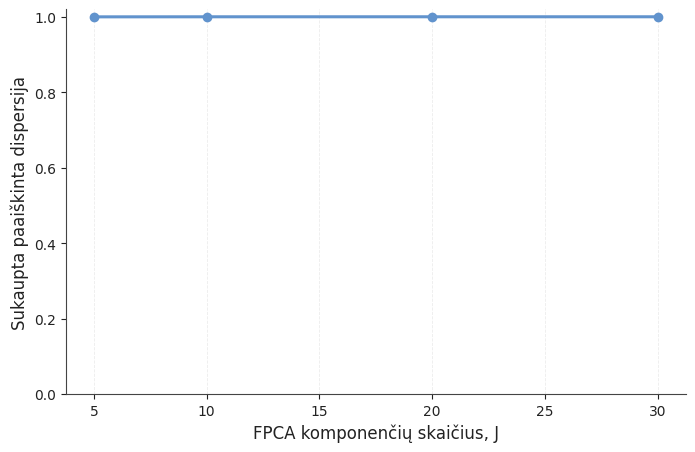

In [11]:
fpca_info_df = pd.DataFrame(fpca_info_rows)

fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(
    fpca_info_df["J"],
    fpca_info_df["cum_explained_variance"],
    marker="o",
    linewidth=2.2,
    color=COLOR_PRIMARY,
)

ax.set_xlabel("FPCA komponenčių skaičius, J")
ax.set_ylabel("Sukaupta paaiškinta dispersija")
ax.set_ylim(0, 1.02)
apply_clean_axes(ax, add_grid=True)
plt.show()


  ## 11. Top-model comparison plot

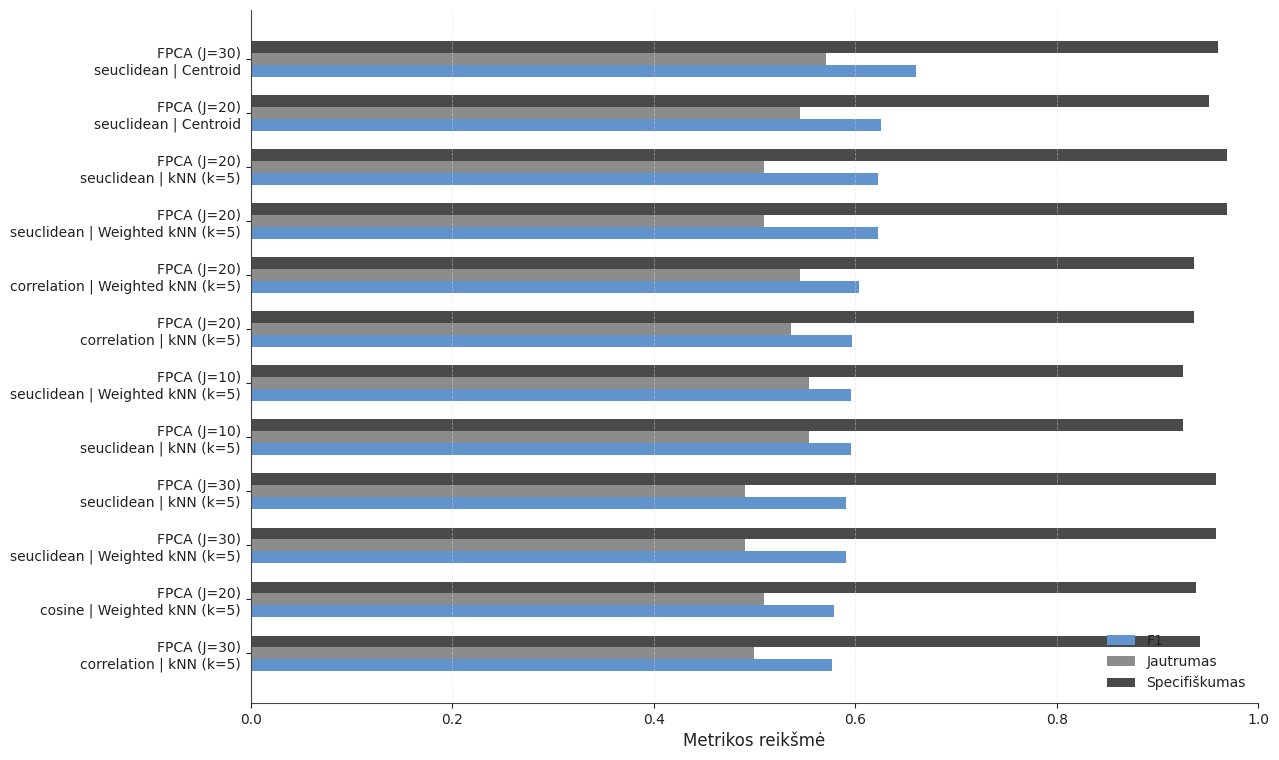

In [12]:
plot_df = results_df.copy()
plot_df["label"] = (
    plot_df["feature_space"]
    + "\n"
    + plot_df["distance"]
    + " | "
    + plot_df["model"]
)

plot_df = plot_df.sort_values("f1", ascending=False).head(TOP_N_PLOT).copy()
plot_df = plot_df.sort_values("f1", ascending=True)

y_pos = np.arange(len(plot_df))
bar_height = 0.22

fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(y_pos - bar_height, plot_df["f1"], height=bar_height, label="F1", color=COLOR_PRIMARY)
ax.barh(y_pos, plot_df["sensitivity"], height=bar_height, label="Jautrumas", color=COLOR_SECONDARY)
ax.barh(y_pos + bar_height, plot_df["specificity"], height=bar_height, label="Specifiškumas", color=COLOR_DARK)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Metrikos reikšmė")
ax.set_xlim(0, 1.0)
ax.legend(frameon=False, loc="lower right")
apply_clean_axes(ax, add_grid=True)
plt.show()


  ## 12. Distance comparison within FPCA space

In [13]:
distance_comparison_df = results_df.pivot_table(
    index=["feature_space", "distance"],
    columns="model",
    values="f1",
)

print("\n=== F1 BY FPCA SETTING AND DISTANCE ===")
display(distance_comparison_df.round(3))



=== F1 BY FPCA SETTING AND DISTANCE ===


model                      Centroid  Medoid  Weighted kNN (k=5)  kNN (k=5)
feature_space distance                                                    
FPCA (J=10)   correlation     0.321   0.378               0.559      0.560
              cosine          0.321   0.395               0.544      0.562
              euclidean       0.324   0.312               0.452      0.443
              mahalanobis     0.324   0.312               0.486      0.469
              manhattan       0.325   0.319               0.451      0.451
              seuclidean      0.500   0.541               0.596      0.596
FPCA (J=20)   correlation     0.321   0.383               0.604      0.597
              cosine          0.321   0.385               0.579      0.574
              euclidean       0.324   0.312               0.411      0.405
              mahalanobis     0.324   0.316               0.446      0.437
              manhattan       0.325   0.318               0.517      0.517
              seuclidean      0.626   0.480               0.623      0.623
FPCA (J=30)   correlation     0.321   0.387               0.577      0.577
              cosine          0.321   0.385               0.557      0.557
              euclidean       0.324   0.312               0.402      0.395
              mahalanobis     0.324   0.316               0.431      0.422
              manhattan       0.325   0.319               0.523      0.523
              seuclidean      0.660   0.477               0.591      0.591
FPCA (J=5)    correlation     0.321   0.315               0.362      0.421
              cosine          0.321   0.400               0.469      0.475
              euclidean       0.324   0.312               0.407      0.398
              mahalanobis     0.324   0.312               0.447      0.420
              manhattan       0.325   0.321               0.422      0.404
              seuclidean      0.444   0.479               0.569      0.562

  ## 13. Eigenspectra from the largest FPCA model

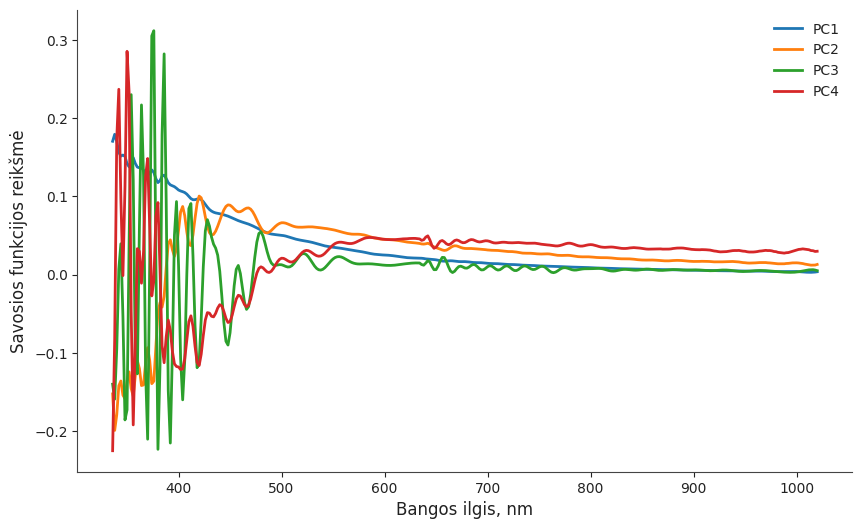

In [14]:
J_plot = max(J_VALUES)
_, _, explained_ratio_plot, variances_plot, mu_plot, Vt_plot = fpca_fit_transform(X_tr, X_te, J_plot)

n_plot = min(4, Vt_plot.shape[0])

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_plot):
    ax.plot(wavelengths, Vt_plot[i], linewidth=2.0, label=f"PC{i + 1}")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Savosios funkcijos reikšmė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 14. Mean normalized spectra by class

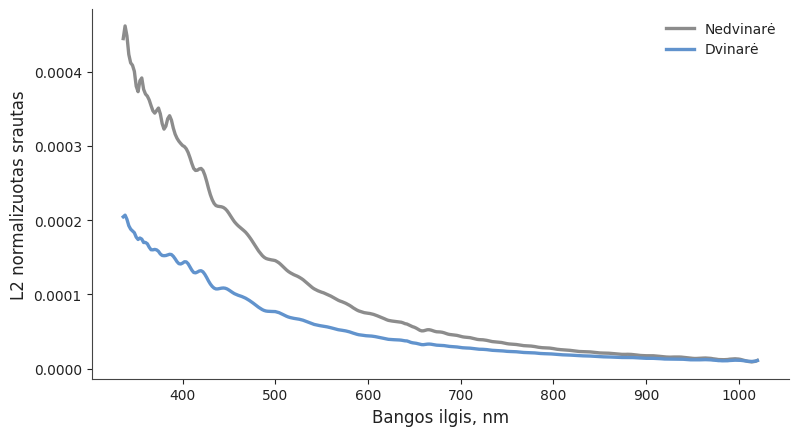

In [15]:
mu_0 = X[y == 0].mean(axis=0)
mu_1 = X[y == 1].mean(axis=0)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, mu_0, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mu_1, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 15. Separation strength across wavelength

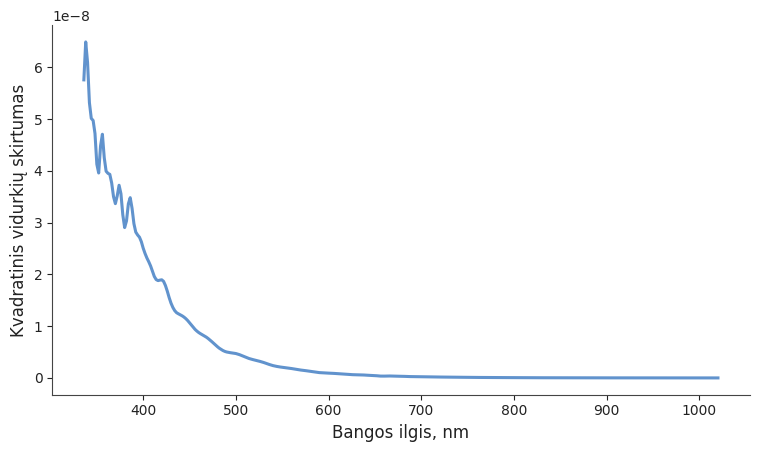

In [16]:
mean_diff_sq = (mu_1 - mu_0) ** 2

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, mean_diff_sq, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Kvadratinis vidurkių skirtumas")
apply_clean_axes(ax, add_grid=False)
plt.show()


  ## 16. Save main outputs

In [17]:
results_df.to_csv(OUT_DIR / "fpca_distance_results.csv", index=False)
best_by_j_df.to_csv(OUT_DIR / "fpca_distance_best_by_j.csv", index=False)
fpca_info_df.to_csv(OUT_DIR / "fpca_explained_variance.csv", index=False)

print("Saved main CSV outputs to:", OUT_DIR)


Saved main CSV outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\02_initial_model_testing


  ## 17. Save figures

In [18]:
# Cumulative explained variance
fig, ax = plt.subplots(figsize=(8.0, 5.0))
ax.plot(
    fpca_info_df["J"],
    fpca_info_df["cum_explained_variance"],
    marker="o",
    linewidth=2.2,
    color=COLOR_PRIMARY,
)
ax.set_xlabel("FPCA komponenčių skaičius, J")
ax.set_ylabel("Sukaupta paaiškinta dispersija")
ax.set_ylim(0, 1.02)
apply_clean_axes(ax, add_grid=True)
save_fig(OUT_DIR / "fig_fpca_cumulative_variance.svg")

# Top models comparison
fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(y_pos - bar_height, plot_df["f1"], height=bar_height, label="F1", color=COLOR_PRIMARY)
ax.barh(y_pos, plot_df["sensitivity"], height=bar_height, label="Jautrumas", color=COLOR_SECONDARY)
ax.barh(y_pos + bar_height, plot_df["specificity"], height=bar_height, label="Specifiškumas", color=COLOR_DARK)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"])
ax.set_xlabel("Metrikos reikšmė")
ax.set_xlim(0, 1.0)
ax.legend(frameon=False, loc="lower right")
apply_clean_axes(ax, add_grid=True)
save_fig(OUT_DIR / "fig_top_fpca_models.svg")

# Eigenspectra
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_plot):
    ax.plot(wavelengths, Vt_plot[i], linewidth=2.0, label=f"PC{i + 1}")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Savosios funkcijos reikšmė")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_fpca_eigenspectra.svg")

# Class means
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, mu_0, linewidth=2.4, color=COLOR_SECONDARY, label="Nedvinarė")
ax.plot(wavelengths, mu_1, linewidth=2.4, color=COLOR_PRIMARY, label="Dvinarė")

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("L2 normalizuotas srautas")
ax.legend(frameon=False, loc="best")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_spectra_fpca_input.svg")

# Mean difference
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(wavelengths, mean_diff_sq, linewidth=2.2, color=COLOR_PRIMARY)

ax.set_xlabel("Bangos ilgis, nm")
ax.set_ylabel("Kvadratinis vidurkių skirtumas")
apply_clean_axes(ax, add_grid=False)
save_fig(OUT_DIR / "fig_class_mean_difference_fpca_input.svg")

print("Saved figure outputs to:", OUT_DIR)


Saved figure outputs to: c:\Users\Lenovo\Documents\VDA\Bakalauras\astroflow_project\results\02_initial_model_testing


  ## 18. Final quick view

In [19]:
print("Best overall model:")
display(best_df.head(1))

print("Best model within each FPCA dimension:")
display(best_by_j_df)

Best overall model:


,representation,feature_space,distance,model,accuracy,precision,recall,sensitivity,specificity,f1
0,Sampled spectra,FPCA (J=30),seuclidean,Centroid,0.883,0.78,0.571,0.571,0.96,0.66


Best model within each FPCA dimension:


,feature_space,representation,distance,model,accuracy,precision,recall,sensitivity,specificity,f1
0,FPCA (J=10),Sampled spectra,seuclidean,kNN (k=5),0.851,0.646,0.554,0.554,0.925,0.596
1,FPCA (J=20),Sampled spectra,seuclidean,Centroid,0.870,0.735,0.545,0.545,0.951,0.626
2,FPCA (J=30),Sampled spectra,seuclidean,Centroid,0.883,0.780,0.571,0.571,0.960,0.660
3,FPCA (J=5),Sampled spectra,seuclidean,Weighted kNN (k=5),0.838,0.606,0.536,0.536,0.914,0.569
